In [1]:
import sys
sys.path.append(r"C:\Users\zhaoh\Desktop\CDS")
import os 
import torch
import random
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns 
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from src.utils import load_video_data, evaluate
from src.data.image.data_loader import ImageDataset
from sklearn.utils.class_weight import compute_class_weight

c:\Users\zhaoh\Desktop\CDS\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


emotion
neutral     4483
joy         1654
surprise    1147
anger       1037
sadness      649
disgust      262
fear         251
Name: count, dtype: int64


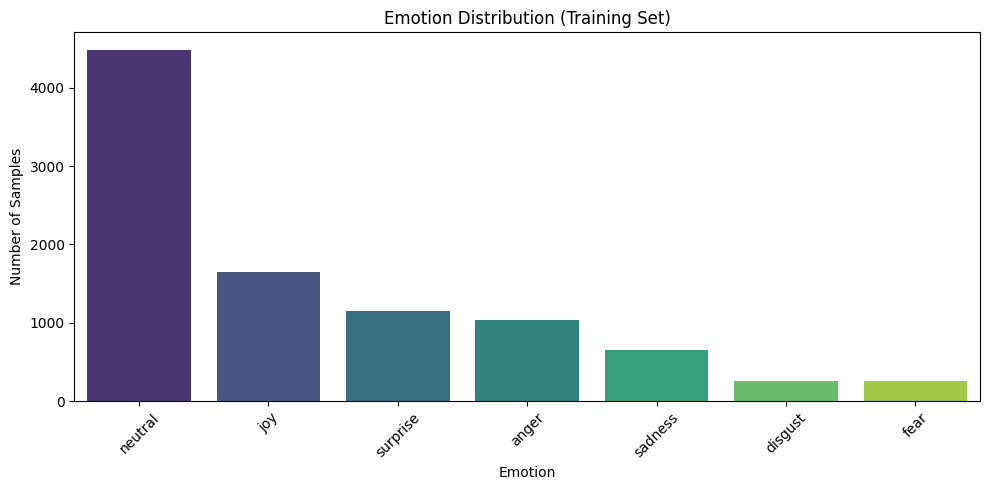

In [2]:
# ---------------------------------
# Convert labels to dataframe
# ---------------------------------
video_dirs, labels, emotion_to_idx = load_video_data(
    metadata_csv="C:/Users/zhaoh/Desktop/processed_train/metadata_extracted.csv",
    frames_root_dir="C:/Users/zhaoh/Desktop/processed_train/frames_extracted/"
)

idx_to_emotion = {v: k for k, v in emotion_to_idx.items()}

labels_np = np.array(labels)

labels_df = pd.DataFrame({
    "label_id": labels_np,
    "emotion": [idx_to_emotion[i] for i in labels_np]
})

# ---------------------------------
# Count samples per emotion
# ---------------------------------
emotion_counts = labels_df["emotion"].value_counts().sort_values(ascending=False)

print(emotion_counts)

# ---------------------------------
# Plot
# ---------------------------------
plt.figure(figsize=(10,5))

sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts.values,
    hue=emotion_counts.index,   # avoids seaborn future warning
    legend=False,
    palette="viridis"
)

plt.title("Emotion Distribution (Training Set)")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

emotion
neutral     835
joy         251
anger       226
surprise    171
sadness     115
disgust      43
fear         29
Name: count, dtype: int64


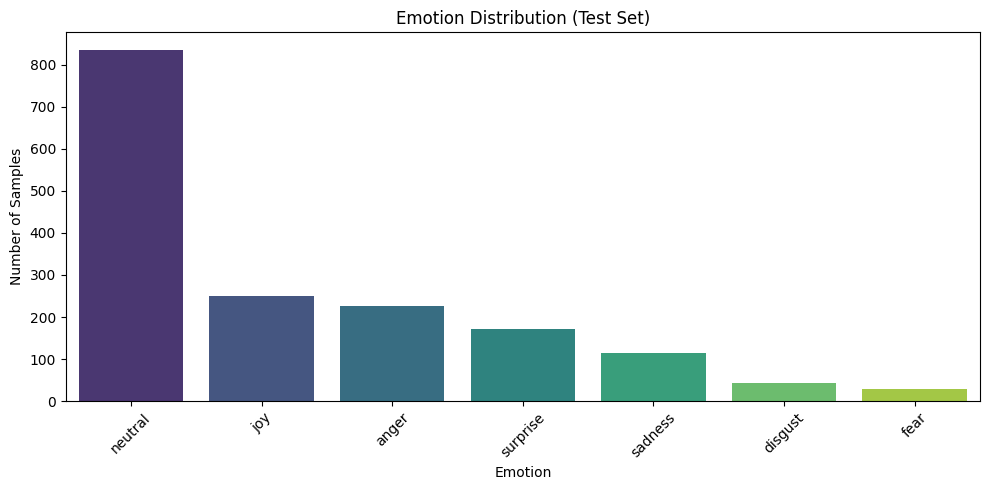

In [3]:
# Convert labels to dataframe
video_dirs, labels, emotion_to_idx = load_video_data(
    metadata_csv="C:/Users/zhaoh/Desktop/processed_test/metadata_extracted.csv",
    frames_root_dir="C:/Users/zhaoh/Desktop/processed_test/frames_test/"
)

idx_to_emotion = {v: k for k, v in emotion_to_idx.items()}

labels_np = np.array(labels)

labels_df = pd.DataFrame({
    "label_id": labels_np,
    "emotion": [idx_to_emotion[i] for i in labels_np]
})

# Count samples per emotion
emotion_counts = labels_df["emotion"].value_counts().sort_values(ascending=False)

print(emotion_counts)

# Plot
plt.figure(figsize=(10,5))

sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts.values,
    hue=emotion_counts.index,   # avoids seaborn future warning
    legend=False,
    palette="viridis"
)

plt.title("Emotion Distribution (Test Set)")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

emotion
anger       1263
disgust      305
fear         280
joy         1905
neutral     5318
sadness      764
surprise    1318
Name: count, dtype: int64


C:\Users\zhaoh\AppData\Local\Temp\ipykernel_19876\1605868149.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


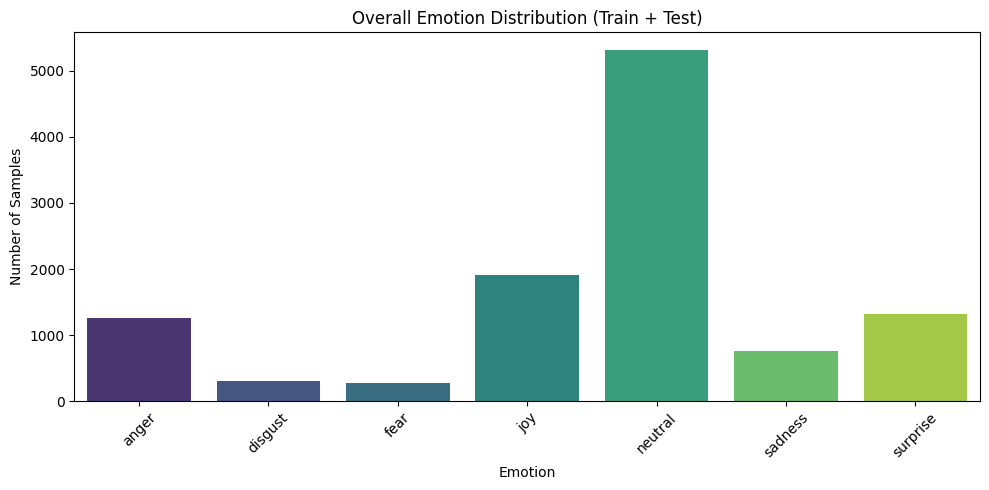

In [4]:
# ---------------------------------
# Convert labels to dataframe
# ---------------------------------
train_video_dirs, train_labels, train_emotion_to_idx = load_video_data(
    metadata_csv="C:/Users/zhaoh/Desktop/processed_train/metadata_extracted.csv",
    frames_root_dir="C:/Users/zhaoh/Desktop/processed_train/frames_extracted/"
)

idx_to_emotion = {v: k for k, v in train_emotion_to_idx.items()}

labels_np = np.array(train_labels)

labels_df = pd.DataFrame({
    "label_id": labels_np,
    "emotion": [idx_to_emotion[i] for i in labels_np]
})

# ---------------------------------
# Count samples per emotion
# ---------------------------------
train_emotion_counts = labels_df["emotion"].value_counts().sort_values(ascending=False)

test_video_dirs, test_labels, test_emotion_to_idx = load_video_data(
    metadata_csv="C:/Users/zhaoh/Desktop/processed_test/metadata_extracted.csv",
    frames_root_dir="C:/Users/zhaoh/Desktop/processed_test/frames_test/"
)

idx_to_emotion = {v: k for k, v in test_emotion_to_idx.items()}

labels_np = np.array(test_labels)

labels_df = pd.DataFrame({
    "label_id": labels_np,
    "emotion": [idx_to_emotion[i] for i in labels_np]
})

# Count samples per emotion
test_emotion_counts = labels_df["emotion"].value_counts().sort_values(ascending=False)

# -------------------------------
# Combine train and test counts
# -------------------------------
overall_counts = train_emotion_counts.add(test_emotion_counts, fill_value=0)
print(overall_counts)
# -------------------------------
# Plot overall distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.barplot(
    x=overall_counts.index,
    y=overall_counts.values,
    palette="viridis"
)

plt.title("Overall Emotion Distribution (Train + Test)")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# pick one video folder
sample_video = video_dirs[1]

# pick one frame inside it
sample_frame = os.listdir(sample_video)[0]
img_path = os.path.join(sample_video, sample_frame)

img = Image.open(img_path)

print("Original image size (W, H):", img.size)

Original image size (W, H): (224, 224)


In [6]:
video_dirs, labels, emotion_to_idx = load_video_data(
    metadata_csv="C:/Users/zhaoh/Desktop/processed_train/metadata.csv",
    frames_root_dir="C:/Users/zhaoh/Desktop/processed_train/frames/"
)

extracted_video_dirs, extracted_labels, extracted_emotion_to_idx = load_video_data(
    metadata_csv="C:/Users/zhaoh/Desktop/processed_test/metadata_extracted.csv",
    frames_root_dir="C:/Users/zhaoh/Desktop/processed_test/frames_test/"
)

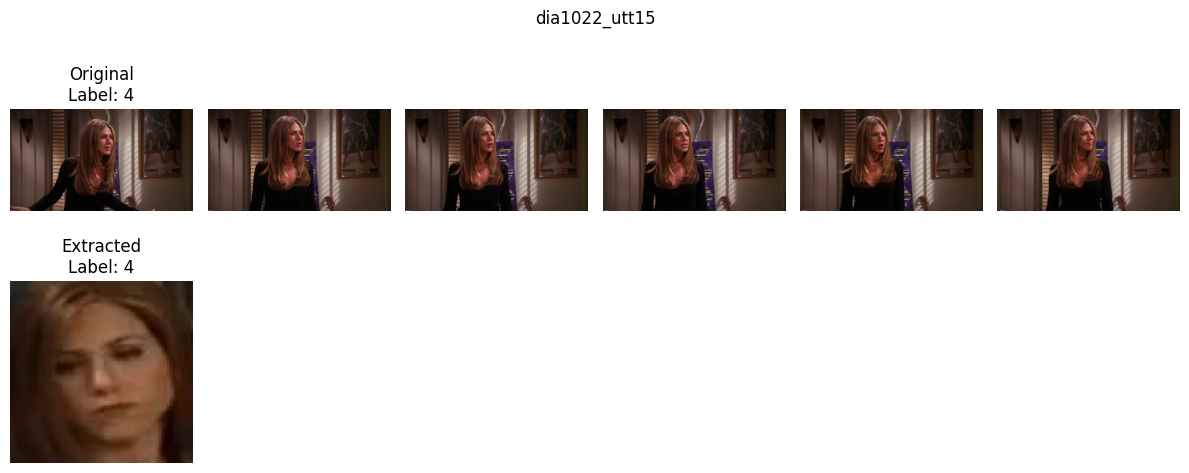

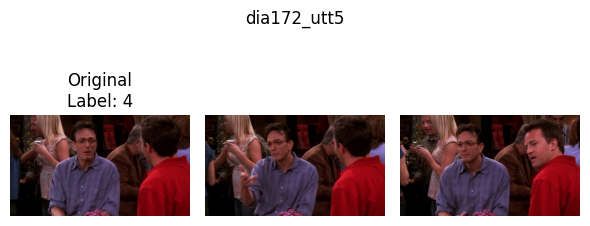

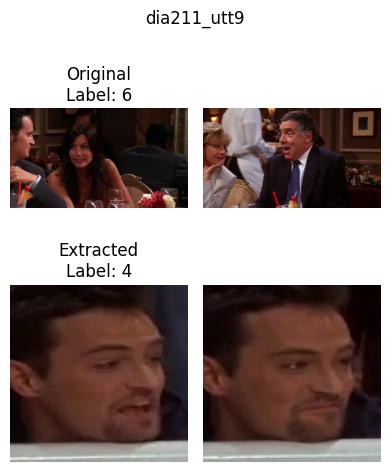

In [7]:
# pick same indices
random.seed(1)
random_indices = random.sample(range(len(extracted_video_dirs)), 3)  # keep small (many images!)

for idx in random_indices:

    folder_orig = video_dirs[idx]
    folder_ext = extracted_video_dirs[idx]

    frames_orig = sorted(os.listdir(folder_orig))
    frames_ext = sorted(os.listdir(folder_ext))

    n_orig = len(frames_orig)
    n_ext = len(frames_ext)

    max_frames = max(n_orig, n_ext)

    plt.figure(figsize=(max_frames * 2, 5))

    # ---------- ORIGINAL ----------
    for i, frame in enumerate(frames_orig):
        img = Image.open(os.path.join(folder_orig, frame)).convert("RGB")

        plt.subplot(2, max_frames, i + 1)
        plt.imshow(img)
        plt.axis("off")

        if i == 0:
            plt.title(f"Original\nLabel: {labels[idx]}")

    # ---------- EXTRACTED ----------
    for i, frame in enumerate(frames_ext):
        img = Image.open(os.path.join(folder_ext, frame)).convert("RGB")

        plt.subplot(2, max_frames, max_frames + i + 1)
        plt.imshow(img)
        plt.axis("off")

        if i == 0:
            plt.title(f"Extracted\nLabel: {extracted_labels[idx]}")

    plt.suptitle(os.path.basename(folder_orig))
    plt.tight_layout()
    plt.show()

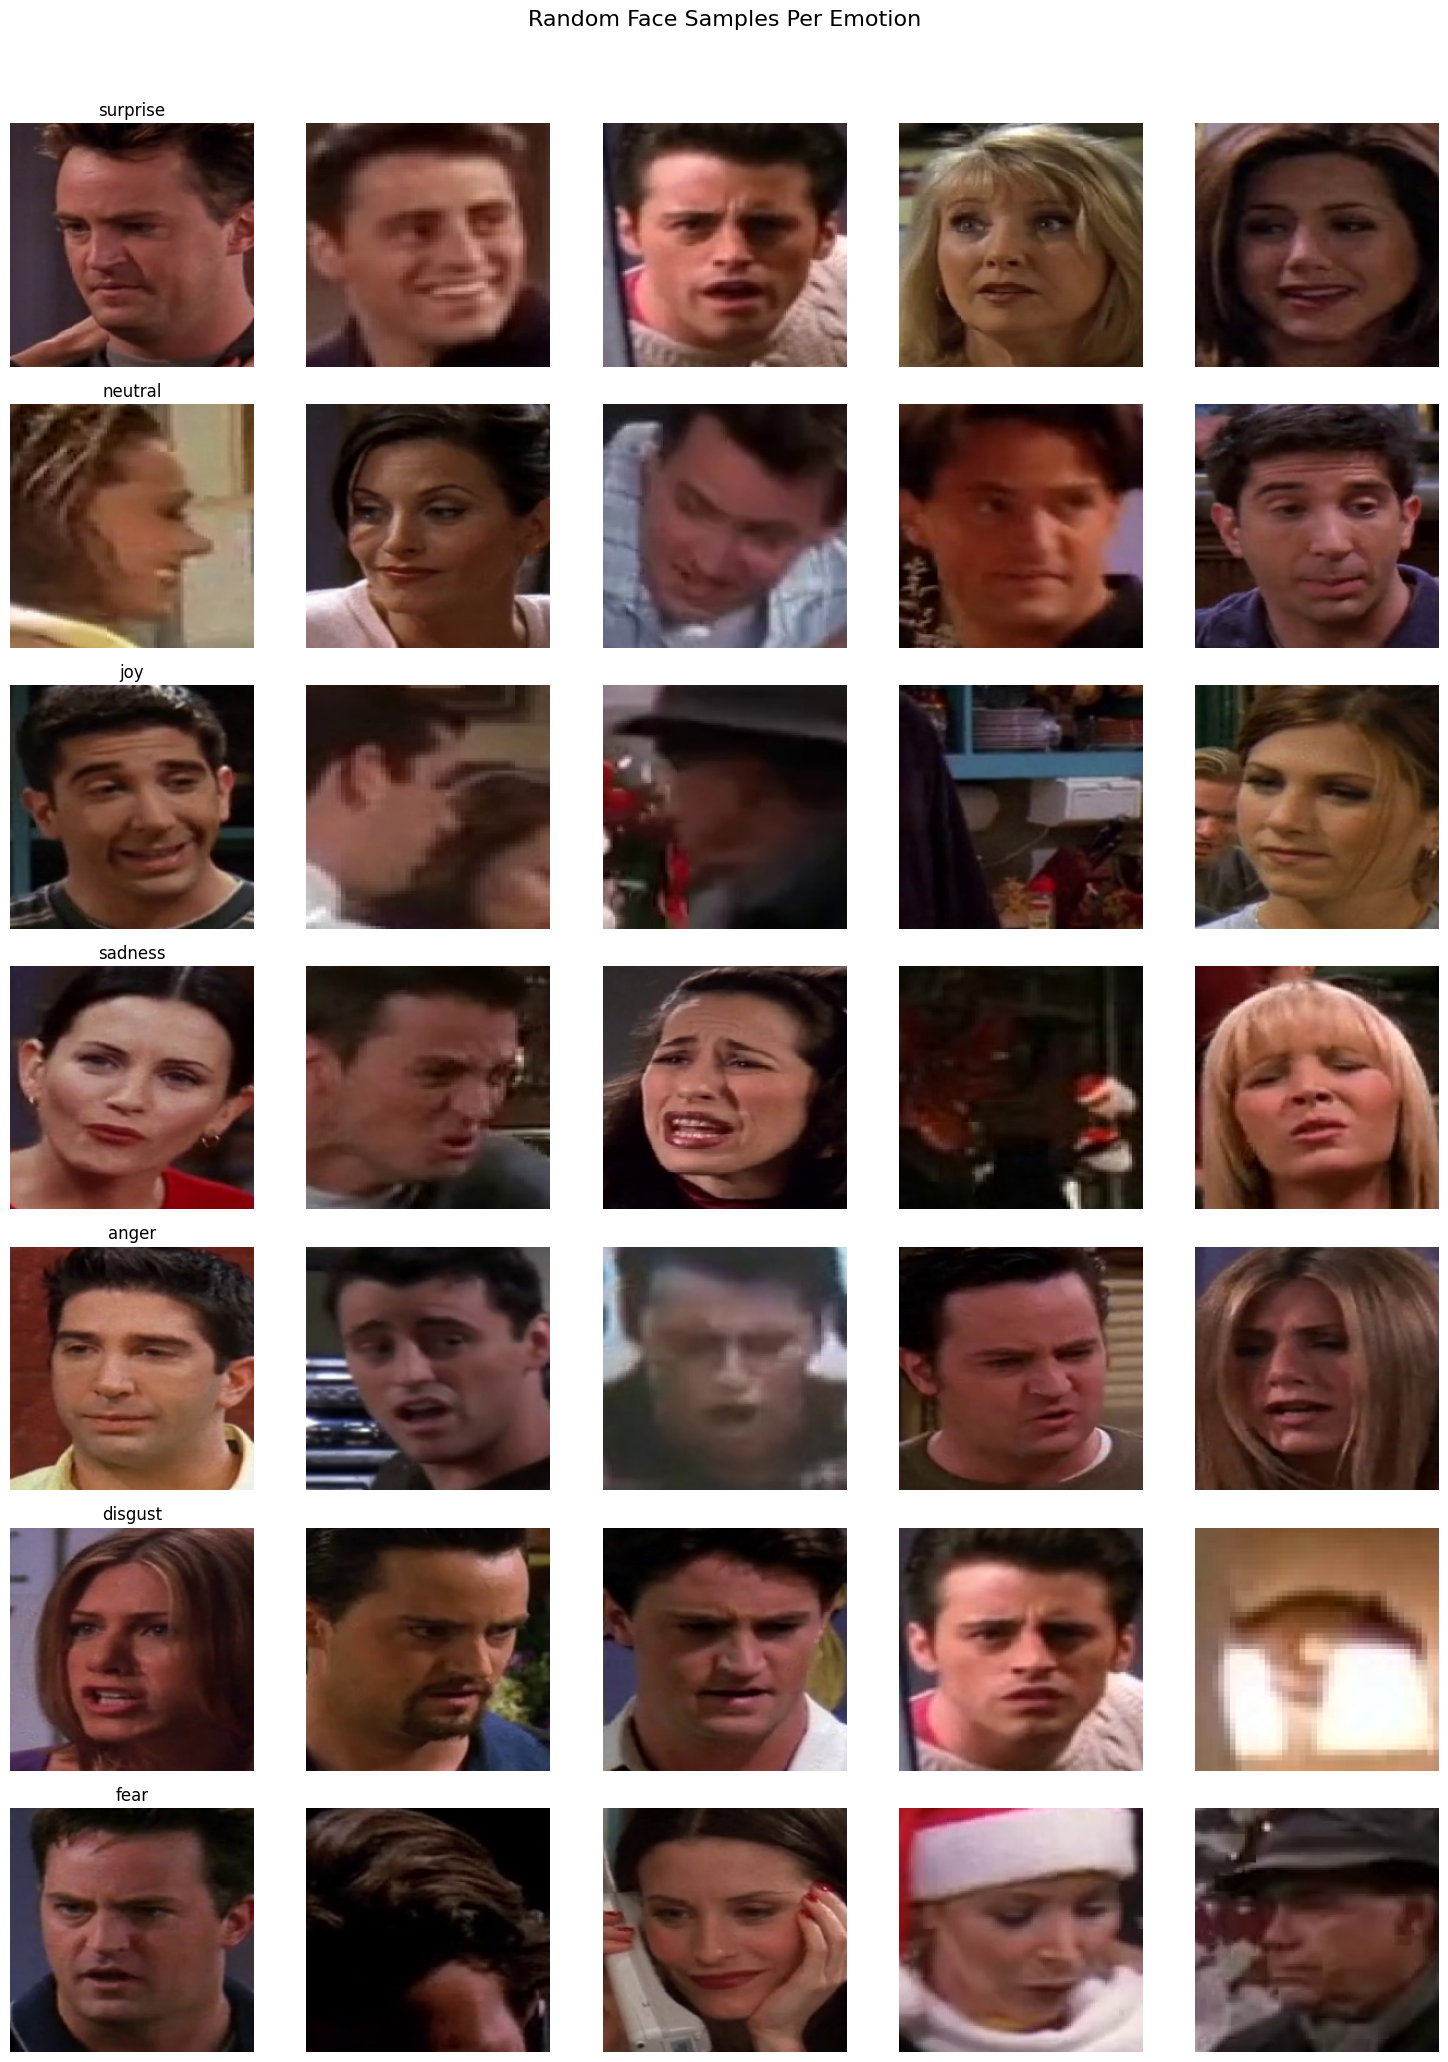

In [11]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

# -----------------------------
# PARAMETERS
# -----------------------------
samples_per_emotion = 5
random.seed(20)

# -----------------------------
# Map indices by emotion
# -----------------------------
emotion_to_indices = defaultdict(list)
for idx, label in enumerate(extracted_labels):  # labels are integers
    emotion_to_indices[label].append(idx)

# If you have a mapping dict like: {0:"happy",1:"sad",...}
idx2emotion = {v:k for k,v in emotion_to_idx.items()}

emotions = list(emotion_to_indices.keys())

# -----------------------------
# Plot grid
# -----------------------------
plt.figure(figsize=(samples_per_emotion * 3, len(emotions) * 3))

for row, emo_idx in enumerate(emotions):

    emo_name = idx2emotion[emo_idx]  # convert index to string name
    
    # Filter out empty folders
    valid_indices = [
        idx for idx in emotion_to_indices[emo_idx]
        if len(os.listdir(extracted_video_dirs[idx])) > 0
    ]

    if len(valid_indices) == 0:
        continue  # skip emotion if no valid frames

    chosen_indices = random.sample(
        valid_indices,
        min(samples_per_emotion, len(valid_indices))
    )

    for col, idx in enumerate(chosen_indices):
        folder = extracted_video_dirs[idx]
        frames = os.listdir(folder)

        frame = random.choice(frames)
        img_path = os.path.join(folder, frame)
        img = Image.open(img_path).convert("RGB")

        ax = plt.subplot(len(emotions), samples_per_emotion,
                         row * samples_per_emotion + col + 1)

        ax.imshow(img)
        ax.axis("off")

        if col == 0:
            ax.set_title(emo_name, fontsize=12)

plt.suptitle("Random Face Samples Per Emotion", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()